<div style="text-align: center;">
    <h1>Python and Advanced Data Sciences: Final Project</h1>
    <p><strong>Instructor:</strong> Batuhan Can</p>
    <p><strong>Members:</strong> Maximillian Seidlitz, Niklas Matusik, Bilal Mert, Bui Ngoc Minh Quach</p>
    <p><strong>Due Date:</strong> 21.07.2026</p>
</div>

# PyTUMs: Open Food Facts

## 1. Data Extraction

### 1.1. Install and Import Required Libraries 

In [7]:
!pip install datasets
!pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np

from datasets import load_dataset


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


### 1.2. Load Dataset

In [3]:
dataset = load_dataset(
    "openfoodfacts/product-database",
    split="food",
    streaming=True
)

In [4]:
sample = dataset.take(10000)
df = pd.DataFrame(list(sample))

### 1.3 Inspect Dataset

In [5]:
df.shape
df.head()

,additives_n,additives_tags,allergens_tags,brands_tags,brands,categories,categories_tags,categories_properties,checkers_tags,ciqual_food_name_tags,...,stores_tags,stores,traces_tags,unique_scans_n,unknown_ingredients_n,unknown_nutrients_tags,vitamins_tags,with_non_nutritive_sweeteners,with_sweeteners,schema_version
0,NaN,None,[en:nuts],[xx:bovetti],Bovetti,"Petit-déjeuners,Produits à tartiner,Produits à...","[en:breakfasts, en:spreads, en:sweet-spreads, ...","{'ciqual_food_code': 31032, 'agribalyse_food_c...",[],[chocolate-spread-with-hazelnuts],...,[],,[],1.0,NaN,[],[],NaN,NaN,1003
1,0.0,[],[],[lagg-s],Lagg's,null,[en:null],"{'ciqual_food_code': None, 'agribalyse_food_co...",[],[unknown],...,None,NaN,[],1.0,0.0,[],[],NaN,NaN,999
2,0.0,[],[],[lagg-s],Lagg's,"Plant-based foods and beverages, Beverages, Ho...","[en:plant-based-foods-and-beverages, en:bevera...","{'ciqual_food_code': 18020, 'agribalyse_food_c...",[],[unknown],...,None,NaN,[],NaN,0.0,[],[],NaN,NaN,999
3,0.0,[],[],[xx:lagg-s],Lagg's,"Beverages and beverages preparations, Plant-ba...","[en:beverages-and-beverages-preparations, en:p...","{'ciqual_food_code': 18020, 'agribalyse_food_c...",[],[unknown],...,None,NaN,[],1.0,1.0,[],[],NaN,NaN,1002
4,0.0,[],[],[lagg-s],Lagg's,NaN,None,"{'ciqual_food_code': None, 'agribalyse_food_co...",[],[unknown],...,None,NaN,[],NaN,0.0,[],[],NaN,NaN,999


In [9]:
# Convert the streamed sample into a pandas DataFrame
sample = dataset.take(10000)
df = pd.DataFrame(list(sample))

# Basic checks
print("Shape:", df.shape)
display(df.head())

Shape: (10000, 111)


,additives_n,additives_tags,allergens_tags,brands_tags,brands,categories,categories_tags,categories_properties,checkers_tags,ciqual_food_name_tags,...,stores_tags,stores,traces_tags,unique_scans_n,unknown_ingredients_n,unknown_nutrients_tags,vitamins_tags,with_non_nutritive_sweeteners,with_sweeteners,schema_version
0,NaN,None,[en:nuts],[xx:bovetti],Bovetti,"Petit-déjeuners,Produits à tartiner,Produits à...","[en:breakfasts, en:spreads, en:sweet-spreads, ...","{'ciqual_food_code': 31032, 'agribalyse_food_c...",[],[chocolate-spread-with-hazelnuts],...,[],,[],1.0,NaN,[],[],NaN,NaN,1003
1,0.0,[],[],[lagg-s],Lagg's,null,[en:null],"{'ciqual_food_code': None, 'agribalyse_food_co...",[],[unknown],...,None,NaN,[],1.0,0.0,[],[],NaN,NaN,999
2,0.0,[],[],[lagg-s],Lagg's,"Plant-based foods and beverages, Beverages, Ho...","[en:plant-based-foods-and-beverages, en:bevera...","{'ciqual_food_code': 18020, 'agribalyse_food_c...",[],[unknown],...,None,NaN,[],NaN,0.0,[],[],NaN,NaN,999
3,0.0,[],[],[xx:lagg-s],Lagg's,"Beverages and beverages preparations, Plant-ba...","[en:beverages-and-beverages-preparations, en:p...","{'ciqual_food_code': 18020, 'agribalyse_food_c...",[],[unknown],...,None,NaN,[],1.0,1.0,[],[],NaN,NaN,1002
4,0.0,[],[],[lagg-s],Lagg's,NaN,None,"{'ciqual_food_code': None, 'agribalyse_food_co...",[],[unknown],...,None,NaN,[],NaN,0.0,[],[],NaN,NaN,999


In [10]:
df.columns.tolist()

['additives_n',
 'additives_tags',
 'allergens_tags',
 'brands_tags',
 'brands',
 'categories',
 'categories_tags',
 'categories_properties',
 'checkers_tags',
 'ciqual_food_name_tags',
 'cities_tags',
 'code',
 'compared_to_category',
 'complete',
 'completeness',
 'correctors_tags',
 'countries_tags',
 'created_t',
 'creator',
 'data_quality_errors_tags',
 'data_quality_info_tags',
 'data_quality_warnings_tags',
 'data_sources_tags',
 'environmental_score_data',
 'environmental_score_grade',
 'environmental_score_score',
 'environmental_score_tags',
 'editors',
 'emb_codes_tags',
 'emb_codes',
 'entry_dates_tags',
 'food_groups_tags',
 'generic_name',
 'images',
 'informers_tags',
 'ingredients_analysis_tags',
 'ingredients_from_palm_oil_n',
 'ingredients_n',
 'ingredients_original_tags',
 'ingredients_percent_analysis',
 'ingredients_tags',
 'ingredients_text',
 'ingredients_with_specified_percent_n',
 'ingredients_with_unspecified_percent_n',
 'ingredients_without_ciqual_codes_n',


In [11]:
df["nutriscore_grade"].value_counts(dropna=False)

nutriscore_grade
e                 3319
a                 1837
d                 1483
unknown           1446
c                 1135
b                  743
not-applicable      37
Name: count, dtype: int64

In [13]:
# Keep only valid Nutri-Score grades
valid_grades = ["a", "b", "c", "d", "e"]

df_clean = df[df["nutriscore_grade"].isin(valid_grades)].copy()

# Check result
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

df_clean["nutriscore_grade"].value_counts()

Original shape: (10000, 111)
Cleaned shape: (8517, 111)


nutriscore_grade
e    3319
a    1837
d    1483
c    1135
b     743
Name: count, dtype: int64

In [14]:
df["nutriments"].iloc[0]

[{'name': 'energy-kcal',
  'value': None,
  '100g': 617.0,
  'serving': None,
  'unit': 'kcal',
  'prepared_value': None,
  'prepared_100g': None,
  'prepared_serving': None,
  'prepared_unit': None},
 {'name': 'proteins',
  'value': None,
  '100g': 8.0,
  'serving': None,
  'unit': 'g',
  'prepared_value': None,
  'prepared_100g': None,
  'prepared_serving': None,
  'prepared_unit': None},
 {'name': 'saturated-fat',
  'value': None,
  '100g': 10.0,
  'serving': None,
  'unit': 'g',
  'prepared_value': None,
  'prepared_100g': None,
  'prepared_serving': None,
  'prepared_unit': None},
 {'name': 'energy',
  'value': None,
  '100g': 2524.0,
  'serving': None,
  'unit': 'kJ',
  'prepared_value': None,
  'prepared_100g': None,
  'prepared_serving': None,
  'prepared_unit': None},
 {'name': 'energy-kj',
  'value': None,
  '100g': 2524.0,
  'serving': None,
  'unit': 'kJ',
  'prepared_value': None,
  'prepared_100g': None,
  'prepared_serving': None,
  'prepared_unit': None},
 {'name': 'sal

In [15]:
# Nutrients we want to use as ML features
nutrient_names = [
    "energy-kcal",
    "fat",
    "saturated-fat",
    "carbohydrates",
    "sugars",
    "fiber",
    "proteins",
    "salt",
    "sodium"
]

# Function to extract the 100g value of a nutrient
def extract_nutrient_100g(nutriments, nutrient_name):
    if not isinstance(nutriments, list):
        return np.nan
    
    for item in nutriments:
        if isinstance(item, dict) and item.get("name") == nutrient_name:
            return item.get("100g")
    
    return np.nan

# Create one column per nutrient
for nutrient in nutrient_names:
    df_clean[f"{nutrient}_100g"] = df_clean["nutriments"].apply(
        lambda x: extract_nutrient_100g(x, nutrient)
    )

# Check the newly created columns
df_clean[[f"{nutrient}_100g" for nutrient in nutrient_names]].head()

,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,617.0,48.000000,10.000000,36.0,32.0,NaN,8.0,0.01,0.004
10,0.0,0.000000,NaN,0.0,NaN,NaN,0.0,0.00,0.000
13,857.0,100.000000,7.140000,0.0,NaN,NaN,0.0,0.00,0.000
14,4590.0,510.000000,76.400002,0.0,0.0,0.0,0.0,12.70,5.100
15,571.0,57.139999,10.710000,0.0,0.0,0.0,0.0,1.34,0.536


In [16]:
features = [
    "energy-kcal_100g",
    "fat_100g",
    "saturated-fat_100g",
    "carbohydrates_100g",
    "sugars_100g",
    "fiber_100g",
    "proteins_100g",
    "salt_100g",
    "sodium_100g"
]

df_clean[features].isnull().sum()

energy-kcal_100g       122
fat_100g               122
saturated-fat_100g    1004
carbohydrates_100g     122
sugars_100g            356
fiber_100g            1388
proteins_100g          122
salt_100g              122
sodium_100g            122
dtype: int64

In [17]:
df_clean[features + ["nutriscore_grade"]].head()

,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutriscore_grade
0,617.0,48.000000,10.000000,36.0,32.0,NaN,8.0,0.01,0.004,e
10,0.0,0.000000,NaN,0.0,NaN,NaN,0.0,0.00,0.000,b
13,857.0,100.000000,7.140000,0.0,NaN,NaN,0.0,0.00,0.000,b
14,4590.0,510.000000,76.400002,0.0,0.0,0.0,0.0,12.70,5.100,e
15,571.0,57.139999,10.710000,0.0,0.0,0.0,0.0,1.34,0.536,d


## 2. Data Cleaning and Preperation

### 2.1 ML Dataset Creation

In [18]:
# Define final features and target
features = [
    "energy-kcal_100g",
    "fat_100g",
    "saturated-fat_100g",
    "carbohydrates_100g",
    "sugars_100g",
    "fiber_100g",
    "proteins_100g",
    "salt_100g",
    "sodium_100g"
]

target = "nutriscore_grade"

# Create modeling dataset
df_model = df_clean[features + [target]].copy()

# Check result
df_model.head()

,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutriscore_grade
0,617.0,48.000000,10.000000,36.0,32.0,NaN,8.0,0.01,0.004,e
10,0.0,0.000000,NaN,0.0,NaN,NaN,0.0,0.00,0.000,b
13,857.0,100.000000,7.140000,0.0,NaN,NaN,0.0,0.00,0.000,b
14,4590.0,510.000000,76.400002,0.0,0.0,0.0,0.0,12.70,5.100,e
15,571.0,57.139999,10.710000,0.0,0.0,0.0,0.0,1.34,0.536,d


### 2.2 Checking Missing Values

In [19]:
# Check missing values
df_model.isnull().sum()

energy-kcal_100g       122
fat_100g               122
saturated-fat_100g    1004
carbohydrates_100g     122
sugars_100g            356
fiber_100g            1388
proteins_100g          122
salt_100g              122
sodium_100g            122
nutriscore_grade         0
dtype: int64

In [20]:
# Check percentage missing values
missing_percent = df_model.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

fiber_100g            16.296818
saturated-fat_100g    11.788188
sugars_100g            4.179876
energy-kcal_100g       1.432429
fat_100g               1.432429
carbohydrates_100g     1.432429
proteins_100g          1.432429
salt_100g              1.432429
sodium_100g            1.432429
nutriscore_grade       0.000000
dtype: float64

### 2.3 Removing Missing Values

In [21]:
# Remove rows with negative values
for col in features:
    df_model = df_model[df_model[col].isna() | (df_model[col] >= 0)]

# Remove unrealistic gram-based values above 100g
gram_features = [
    "fat_100g",
    "saturated-fat_100g",
    "carbohydrates_100g",
    "sugars_100g",
    "fiber_100g",
    "proteins_100g",
    "salt_100g",
    "sodium_100g"
]

for col in gram_features:
    df_model = df_model[df_model[col].isna() | (df_model[col] <= 100)]

# Remove unrealistic energy values
df_model = df_model[df_model["energy-kcal_100g"].isna() | (df_model["energy-kcal_100g"] <= 1000)]

print(df_model.shape)

(6092, 10)


In [22]:
# Check class distribution after cleaning
df_model["nutriscore_grade"].value_counts()

nutriscore_grade
a    1681
e    1663
d    1109
c     957
b     682
Name: count, dtype: int64

In [27]:
# Class distribution in percentage
df_model["nutriscore_grade"].value_counts(normalize=True) * 100

nutriscore_grade
a    27.593565
e    27.298096
d    18.204202
c    15.709127
b    11.195010
Name: proportion, dtype: float64

In [29]:
df_model.isnull().sum()

energy-kcal_100g      0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
fiber_100g            0
proteins_100g         0
salt_100g             0
sodium_100g           0
nutriscore_grade      0
dtype: int64

In [25]:
# Median imputation
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df_model[features] = imputer.fit_transform(df_model[features])

df_model.isnull().sum()

energy-kcal_100g      0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
fiber_100g            0
proteins_100g         0
salt_100g             0
sodium_100g           0
nutriscore_grade      0
dtype: int64

## 3. Exploratory Data Analysis (EDA)

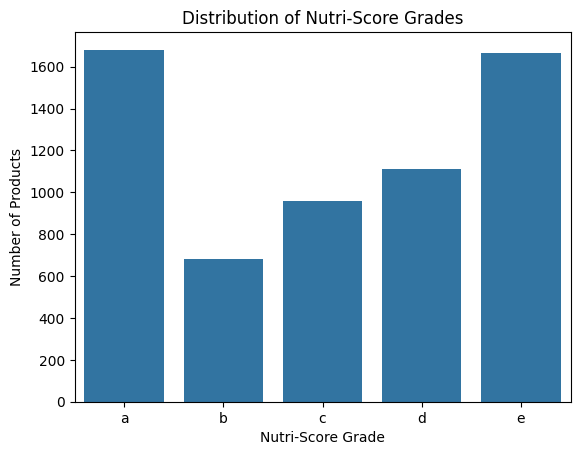

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    data=df_model,
    x="nutriscore_grade",
    order=["a", "b", "c", "d", "e"]
)

plt.title("Distribution of Nutri-Score Grades")
plt.xlabel("Nutri-Score Grade")
plt.ylabel("Number of Products")
plt.show()